# Indian Stock Market Analysis — 2024
**Tools:** Python, yfinance, matplotlib, pandas  
**Stocks analysed:** TCS, Reliance Industries, HDFC Bank, Infosys  
**Period:** January 2024 — December 2024

## Objective
Compare the price performance and returns of four major Indian stocks 
across 2024 to identify which sector and stock delivered best returns.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

## Single Stock Price Chart — TCS 2024
Looking at raw closing price of TCS throughout 2024

[*********************100%***********************]  1 of 1 completed


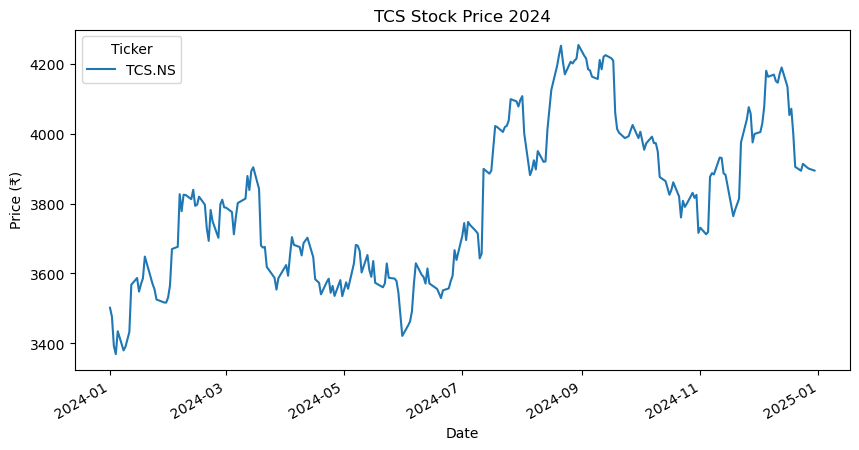

In [2]:
stock = yf.download("TCS.NS", start="2024-01-01", end="2024-12-31")
stock['Close'].plot(title="TCS Stock Price 2024", figsize=(10,5))
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.show()

## Basic Statistics — TCS 2024

In [3]:
print("Average price: ", round(stock['Close'].mean(),2))
print("Highest price: ", round(stock['Close'].max(),2))
print("Lowest price: ", round(stock['Close'].min(),2))

Average price:  Ticker
TCS.NS    3808.68
dtype: float64
Highest price:  Ticker
TCS.NS    4253.91
dtype: float64
Lowest price:  Ticker
TCS.NS    3369.29
dtype: float64


## Multi Stock Price Comparison
Comparing absolute prices of all four stocks — 
note: higher price does not mean better performance

[*********************100%***********************]  4 of 4 completed


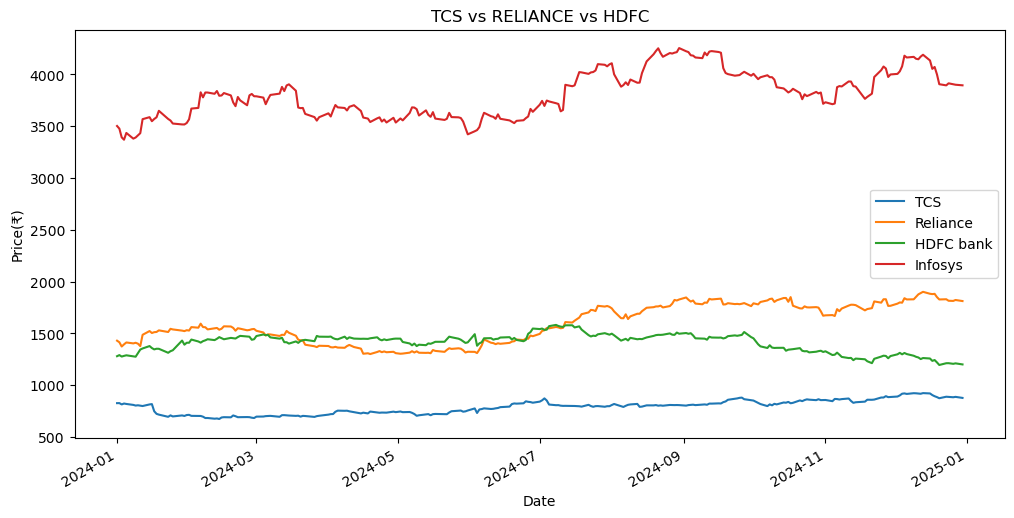

In [4]:
stocks = yf.download(["TCS.NS","RELIANCE.NS","HDFCBANK.NS","INFY.NS"],
                      start = "2024-01-01", end = "2024-12-31")
stocks['Close'].plot(title = "TCS vs RELIANCE vs HDFC", 
                     figsize = (12,6))
plt.xlabel("Date")
plt.ylabel("Price(₹)")
plt.legend(["TCS","Reliance","HDFC bank","Infosys"])
plt.show()

## Cumulative Returns Comparison
Normalising all stocks to ₹1 invested on January 1 2024
to fairly compare performance regardless of share price

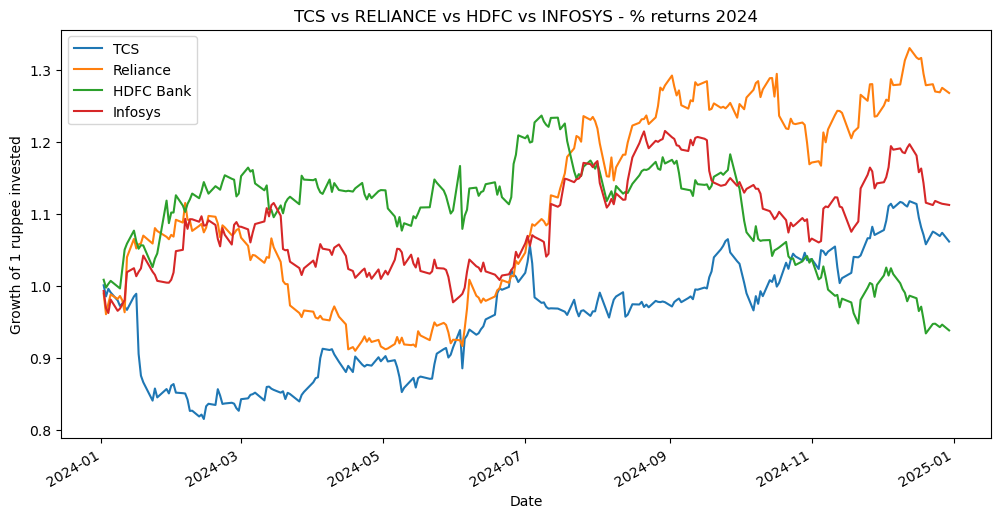

In [5]:
returns = stocks['Close'].pct_change()
cumulative = (1 + returns).cumprod()
cumulative.plot(title = "TCS vs RELIANCE vs HDFC vs INFOSYS - % returns 2024", figsize = (12, 6))
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 invested")
plt.legend(["TCS","Reliance","HDFC Bank","Infosys"])
plt.show()

## Daily Returns Analysis — TCS 2024
How much did TCS move each day throughout 2024

[*********************100%***********************]  1 of 1 completed


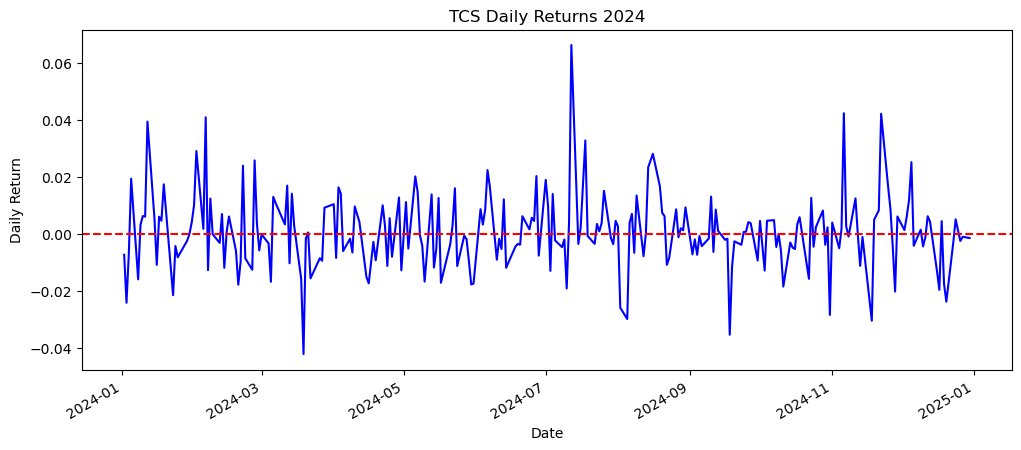

In [6]:
tcs = yf.download("TCS.NS", start="2024-01-01", end="2024-12-31")
tcs['Returns'] = tcs['Close'].pct_change()

tcs['Returns'].plot(title="TCS Daily Returns 2024",
                    figsize=(12,5),
                    color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [7]:
print("Average daily returns: ", round(tcs['Returns'].mean()*100,3), "%")
print("Best single day: ", round(tcs['Returns'].max()*100,3), "%")
print("Worst single day: ", round(tcs['Returns'].min()*100,3), "%")
print("Positive days: ", (tcs['Returns'] > 0).sum())
print("Negative days: ", (tcs['Returns'] < 0).sum())

Average daily returns:  0.052 %
Best single day:  6.633 %
Worst single day:  -4.219 %
Positive days:  118
Negative days:  126


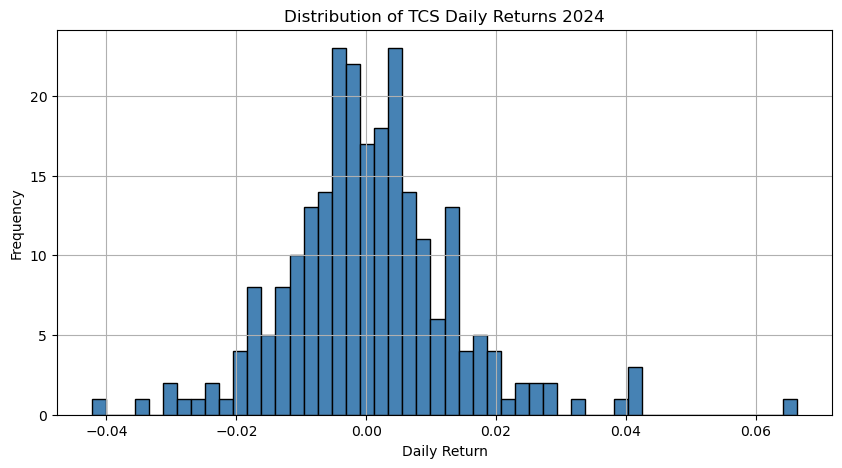

In [8]:
tcs['Returns'].hist(bins=50,
                    figsize=(10,5),
                    color='steelblue',
                    edgecolor='black')
plt.title("Distribution of TCS Daily Returns 2024")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## Key Findings

**Price Analysis:**
- TCS average price in 2024: ₹3,808
- TCS range: ₹3,369 (lowest) to ₹4,253 (highest)

**Returns Comparison:**
- Reliance delivered strongest returns — approximately 27% gain
- TCS had worst first half, dropped 18% by March, recovered to 6% gain by year end
- Infosys steady performer throughout — approximately 11% gain
- HDFC Bank most volatile stock of the four

**Market Event:**
- All four stocks dropped simultaneously in October 2024
- Cause: FII outflows triggered by China stimulus announcement
- Shows how global events impact Indian markets regardless of company fundamentals

**Returns Distribution:**
- TCS daily returns roughly follow a normal bell curve
- Most days show small movements close to 0%
- Extreme moves rare but present on both sides